# **Setup OBLW - 04:  Zscore Generation**

## **0. Setup**

In [69]:
# Load packages
using Revise
using NeuralLongwave
using CairoMakie

In [20]:
# Build together raw data dir
RAW_DIR = raw_data_dir("OBLW", "02_offline", "01_training_data")

# Choose subset of ICs (1:3 are training, 4 is validation)
ICs = 1:3

# Define to be fitted output forms
FORMS = (; 
    linear = LinearOutput(),            # a + b * T
    planck = PlanckOutput()             # a + b * T^4
);

In [ ]:
# Define plot scaling
scaled(k; kwargs...) = (; textwidth_cm = 15.0 * k,
                          fontsize     =  9   * k,
                          linewidth    =  1.2 * k,
                          markersize   =  7   * k,
                          kwargs...)

sc = scaled(1.5);

## **1. Calculation**

In [22]:
# Load column IO data derived in 03_column_io_traininig.ipynb
column_io = NeuralLongwave.load(; dir = column_io_dir("OBLW", "training_data"), file = "column_io.jld2")

# Calculate output form coefficients by fitting
coeffs = (; 
    linear = fit_coeffs(LinearOutput(), column_io),
    planck = fit_coeffs(PlanckOutput(), column_io)
);

(linear = (coeffs = (t1 = Float32[-2.1460423f-6 -1.5643913f-6 … -4.2242442f-5 -6.3763146f-5; -2.1392568f-6 -1.553227f-6 … -4.224063f-5 -6.405776f-5; … ; -3.334192f-6 -1.7589491f-6 … -2.161683f-5 -2.051906f-5; -3.4537632f-6 -1.8784766f-6 … -2.1844746f-5 -2.4605586f-5], t2 = Float32[-6.432731f-8 -6.064258f-8 … -9.394437f-7 -1.7936192f-6; -6.4391195f-8 -6.049555f-8 … -9.4160123f-7 -1.800251f-6; … ; -6.382345f-8 -1.6276367f-8 … 2.273535f-7 1.6554262f-7; -6.605424f-8 -1.8563215f-8 … 2.2006398f-7 6.96306f-8], o1 = Float32[269.98248, 269.9214, 269.56024, 269.05188, 270.0393, 271.58844, 272.2914, 272.8504, 272.97464, 273.12787  …  267.4855, 267.10202, 266.3277, 265.25482, 268.16202, 287.0492, 288.94534, 289.78064, 291.9683, 290.92798], o2 = Float32[0.511916, 0.5212689, 0.52834684, 0.540271, 0.5716414, 0.615091, 0.64029807, 0.65583444, 0.6584943, 0.65561396  …  0.73414224, 0.73446643, 0.7423365, 0.68725735, 0.6020966, 0.6296978, 0.6449407, 0.7466156, 0.9008318, 0.964141], o3 = Float32[1.7771984

In [49]:
# Derive zscore stats
zs = derive_zscore(;
    column_io = column_io,
    coeffs    = coeffs,
    scheme    = "OBLW",
    unit      = "default",
    fit_forms = FORMS,
);

┌ Info: Info file written to c:\Code\NeuralLongwave.jl\data\zscore\OBLW\default\info.toml!
└ @ NeuralLongwave c:\Code\NeuralLongwave.jl\src\utils\io.jl:227
┌ Info: Zscore statistics OBLW_default stored at c:\Code\NeuralLongwave.jl\data\zscore\OBLW\default!
└ @ NeuralLongwave c:\Code\NeuralLongwave.jl\src\data\derive_zscore.jl:63


## **2. Histograms**

### 2.1. Histograms IO

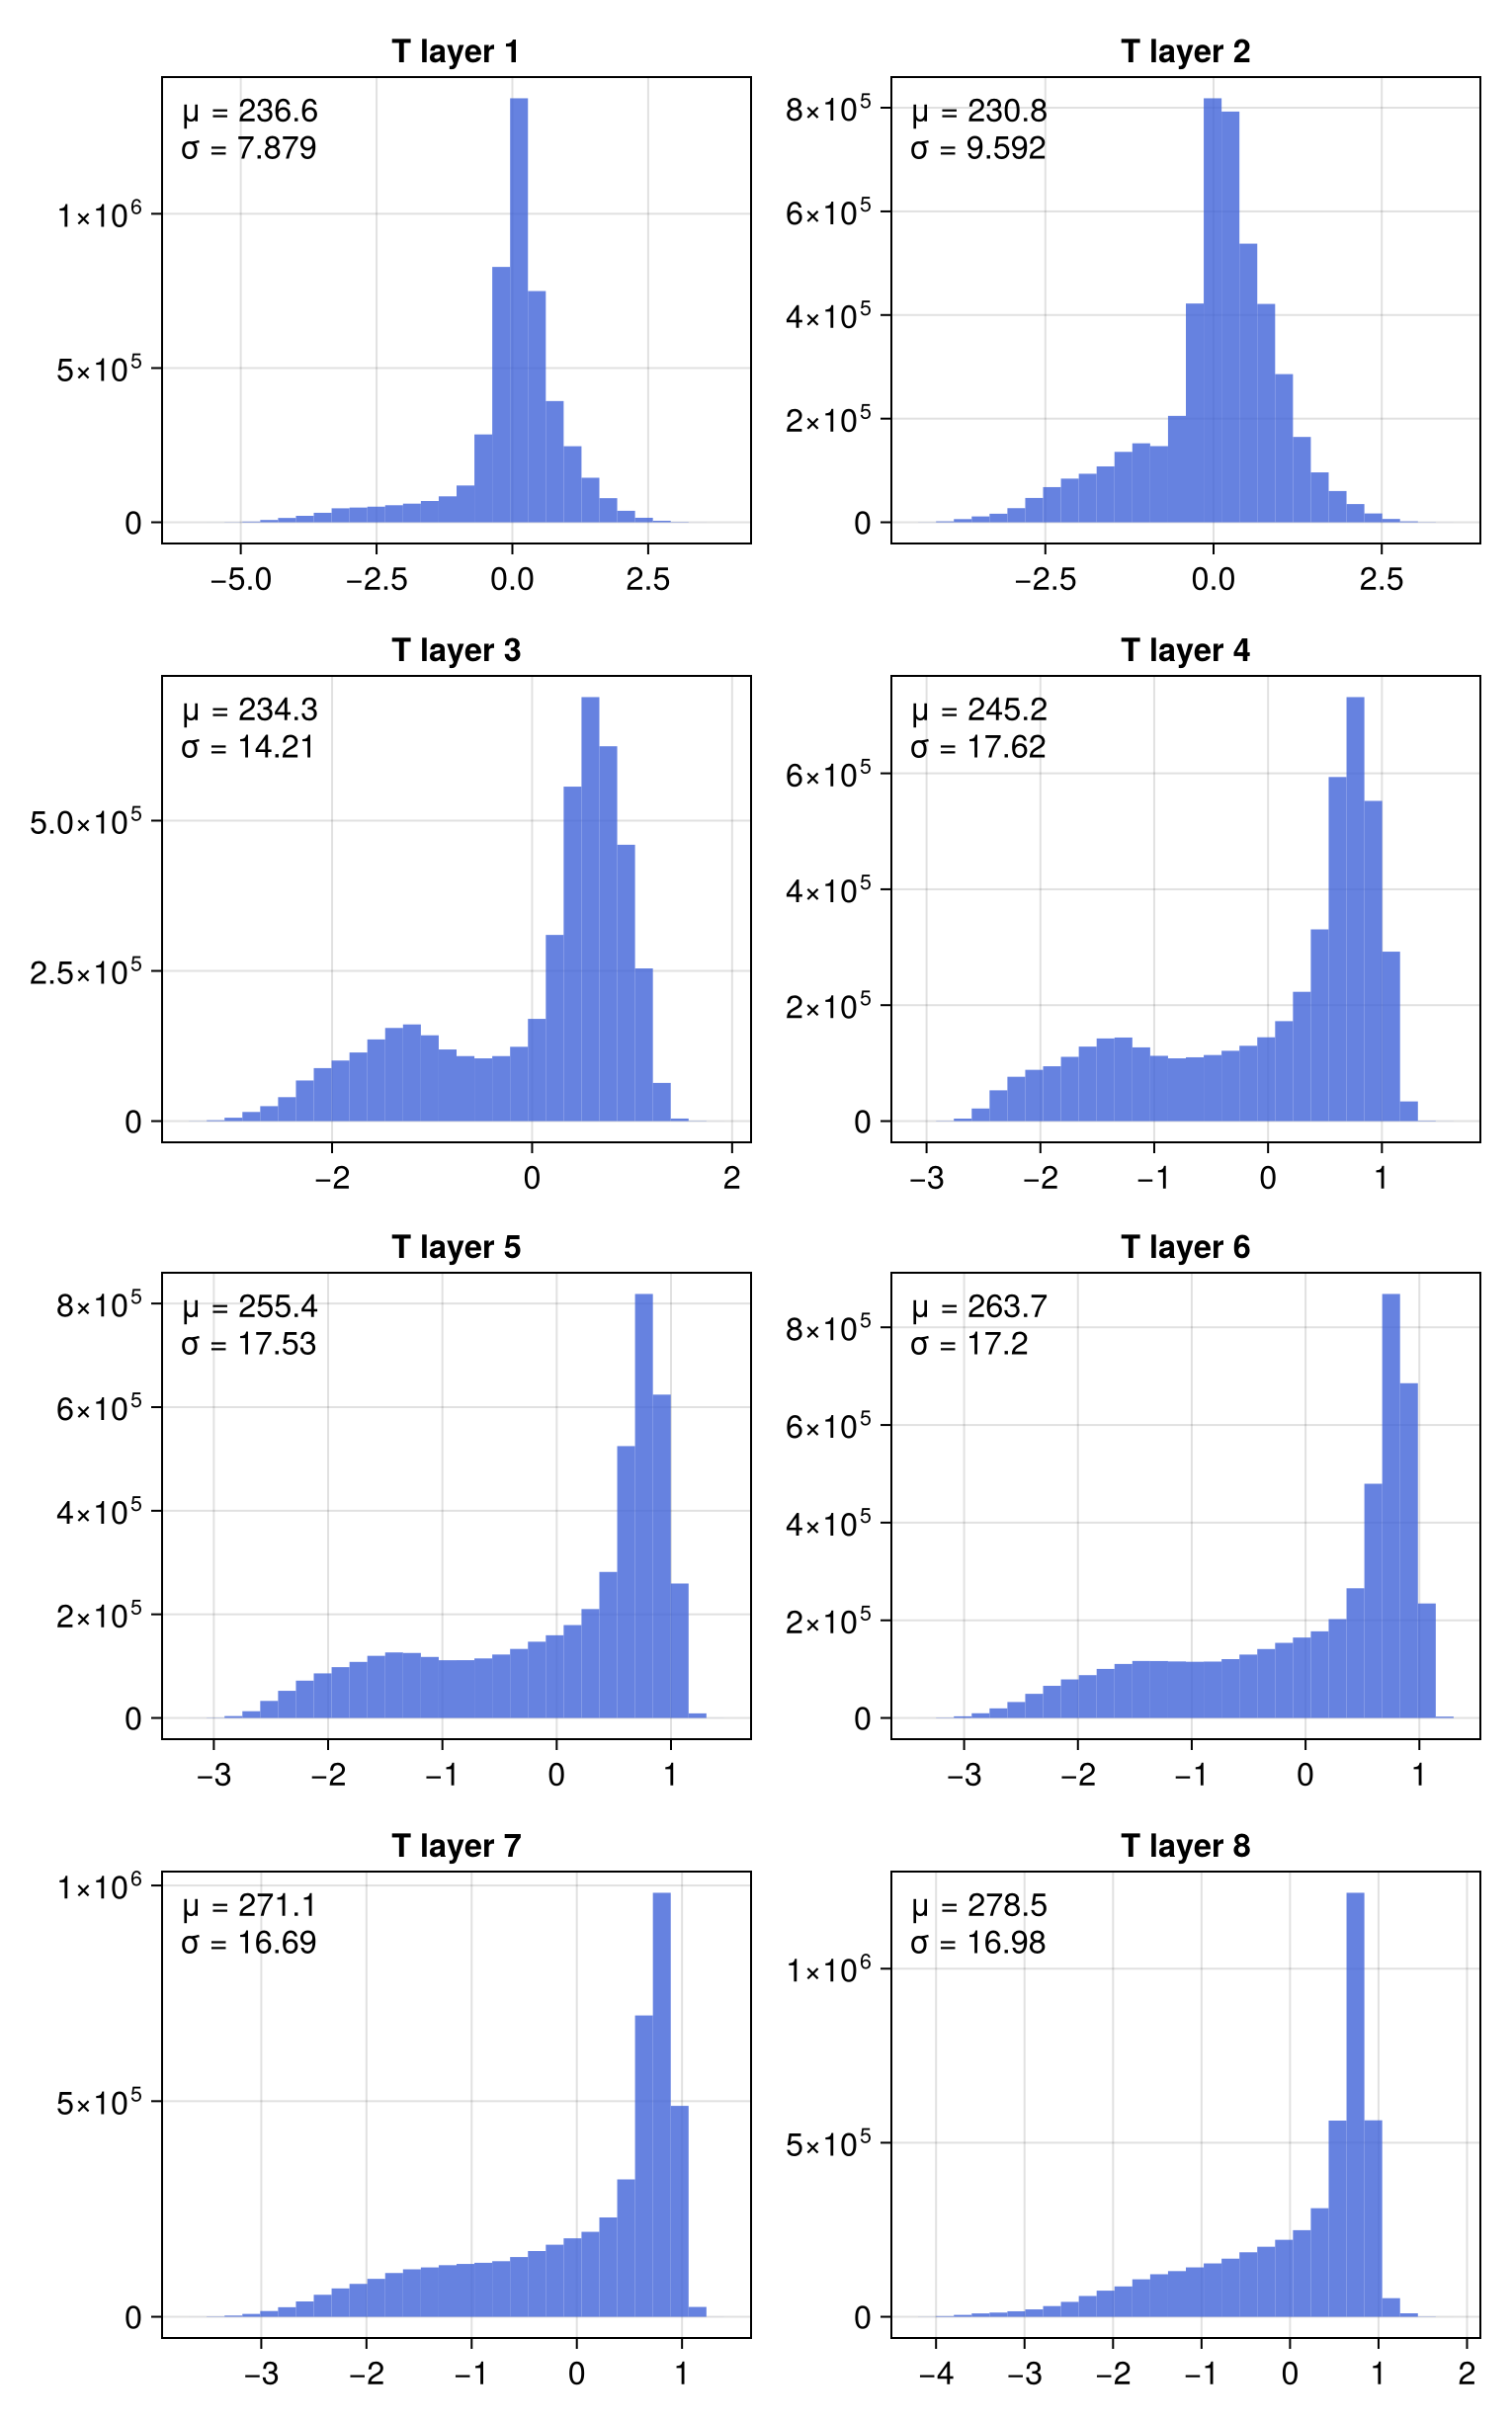

In [72]:
# Temperature
h_T = plot_hist(column_io.fields, zs.fields, (:T), style=sc)  

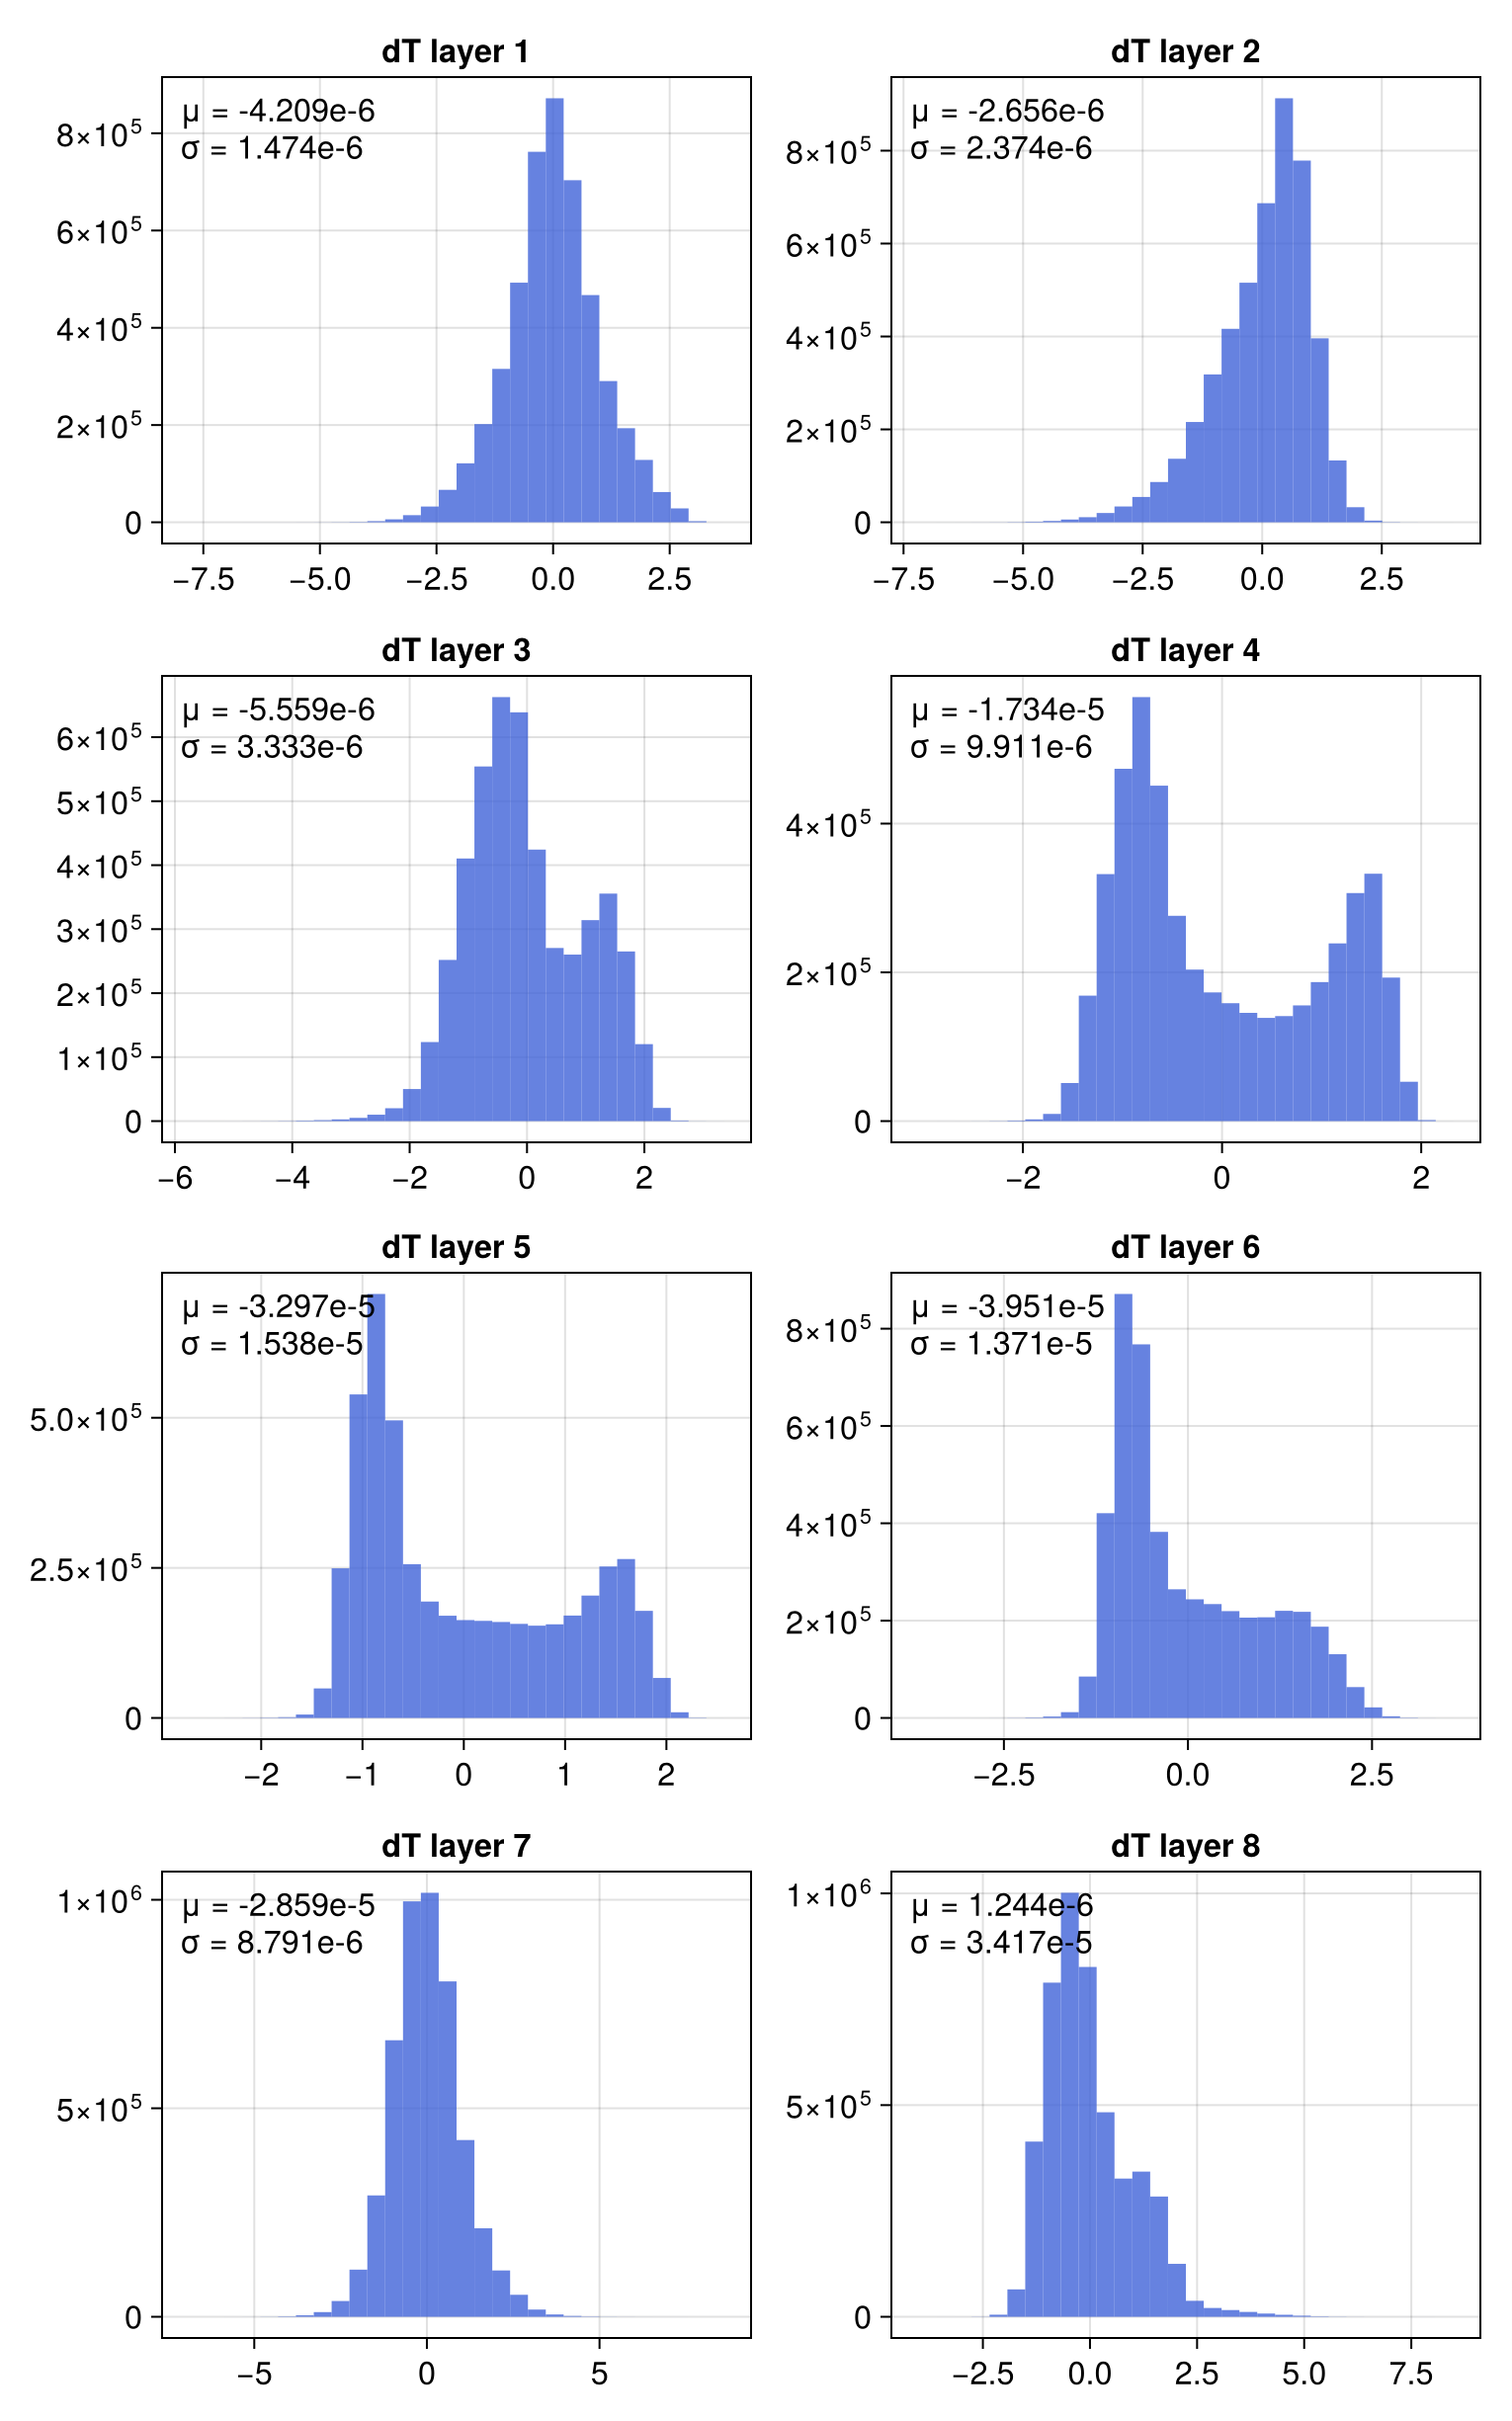

In [73]:
# Temperature tendencies
h_dT = plot_hist(column_io.fields, zs.fields, (:dT), style=sc)  

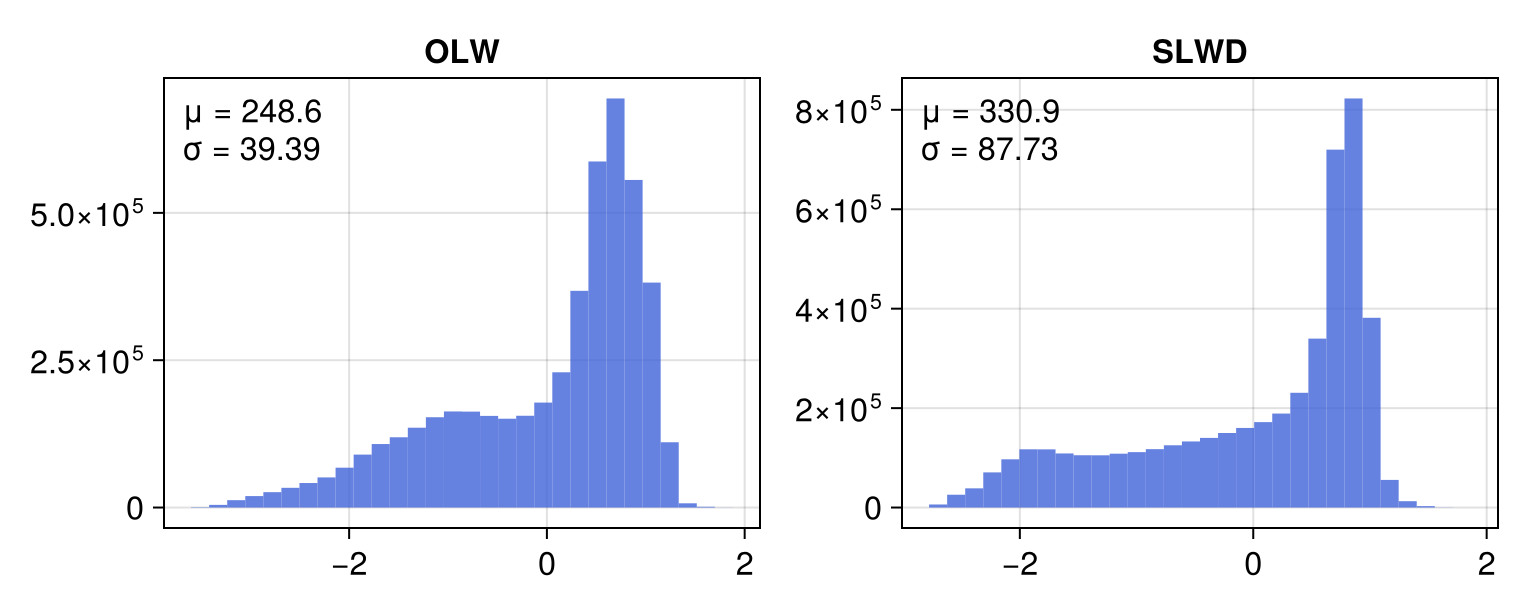

In [74]:
# Fluxes
h_flux = plot_hist(column_io.fields, zs.fields, (:olw, :slwd), style=sc)  

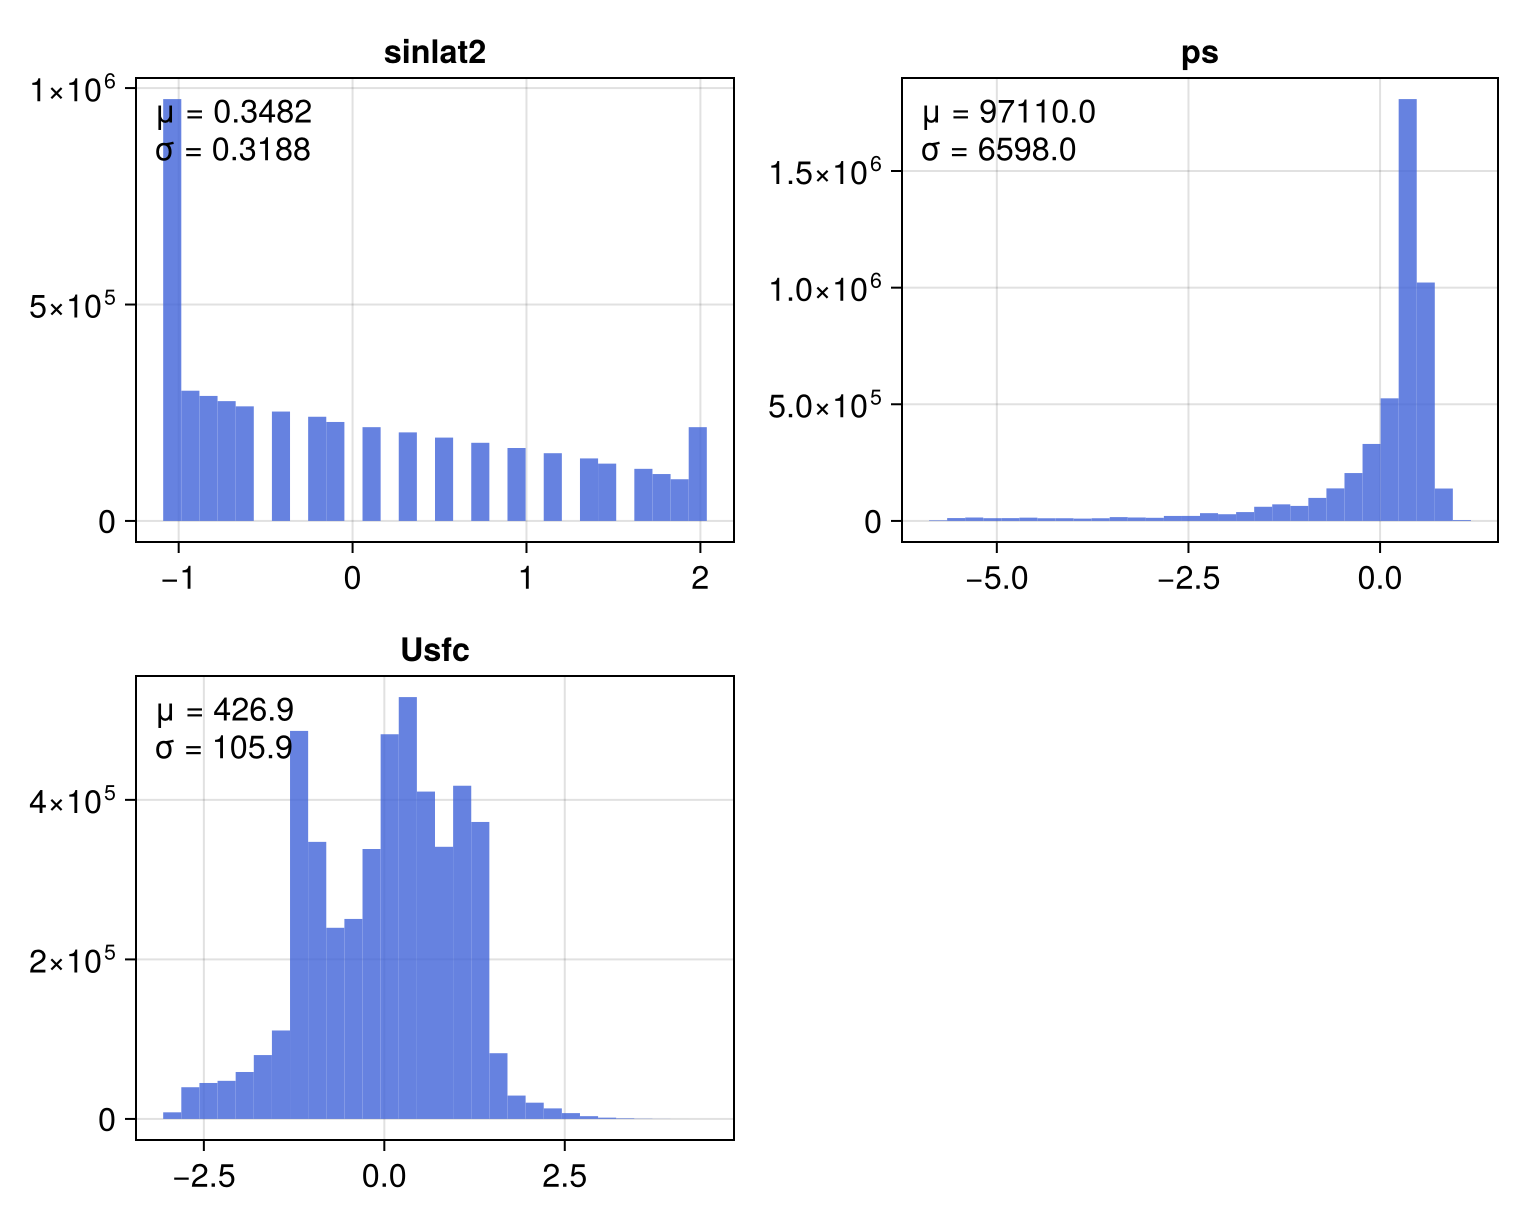

In [86]:
# Input scalars
h_scalar = plot_hist(column_io.fields, zs.fields, (:sinlat2, :ps, :Usfc), style=sc)  

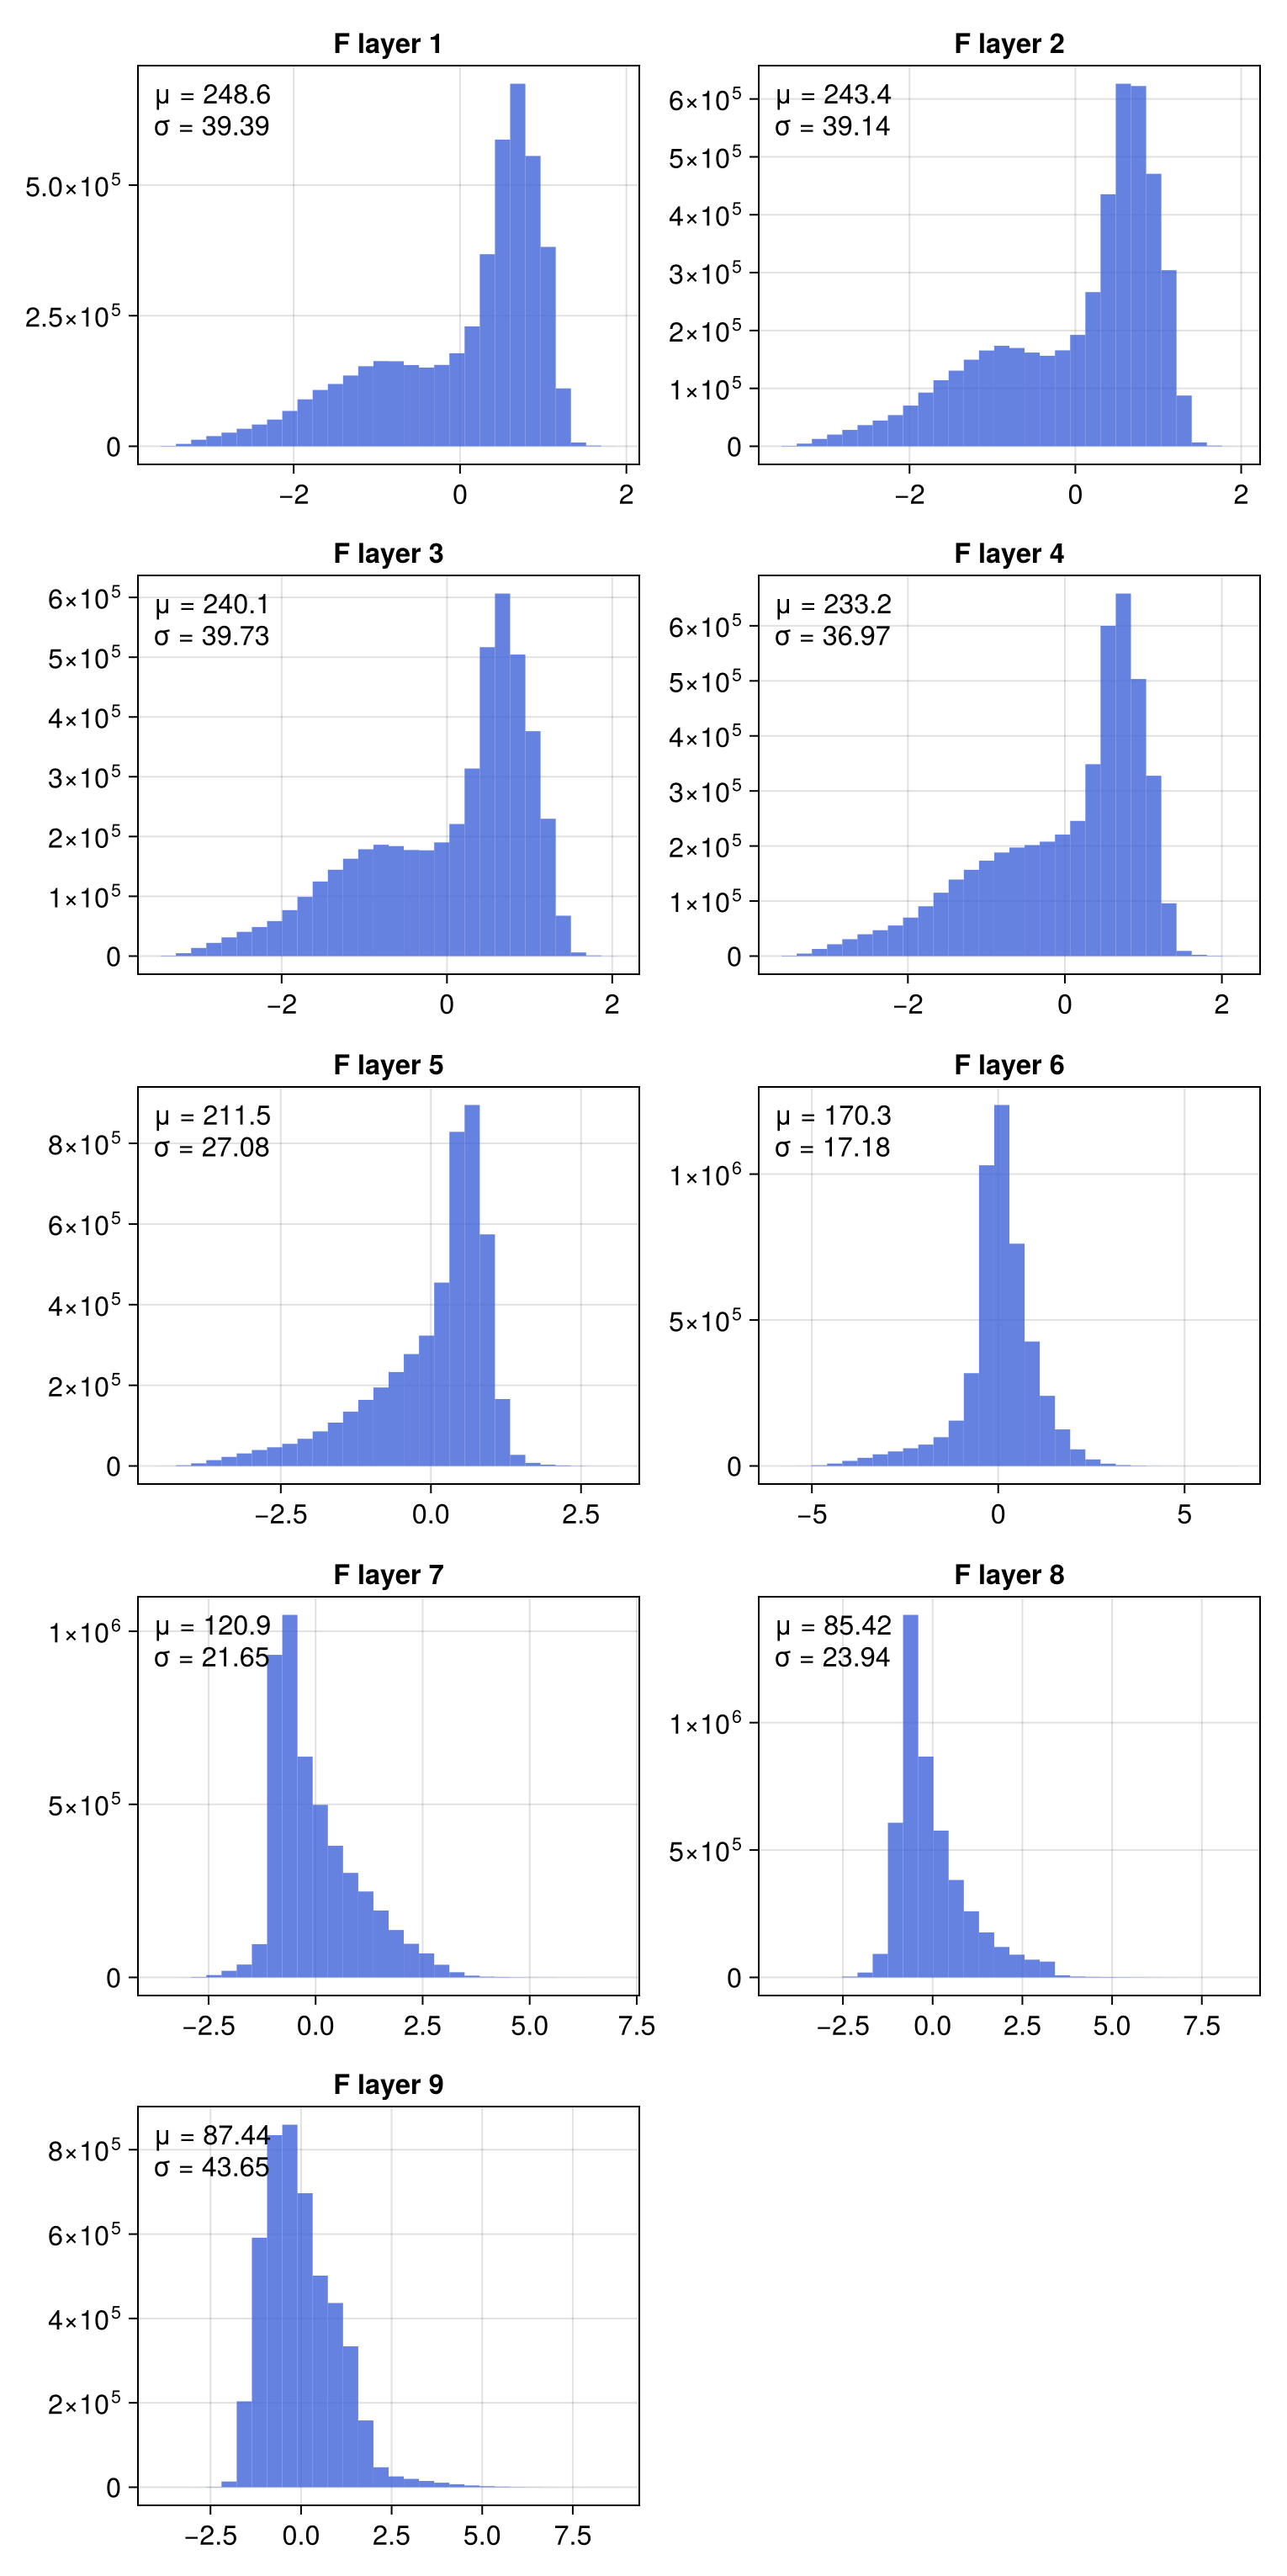

In [76]:
# Net fluxes at layer interfaces
h_net_fluxes = plot_hist(column_io.fields, zs.fields, (:F), style=sc)  

### 2.2. Histograms Output form Coefficients

#### 2.2.1. Temperature

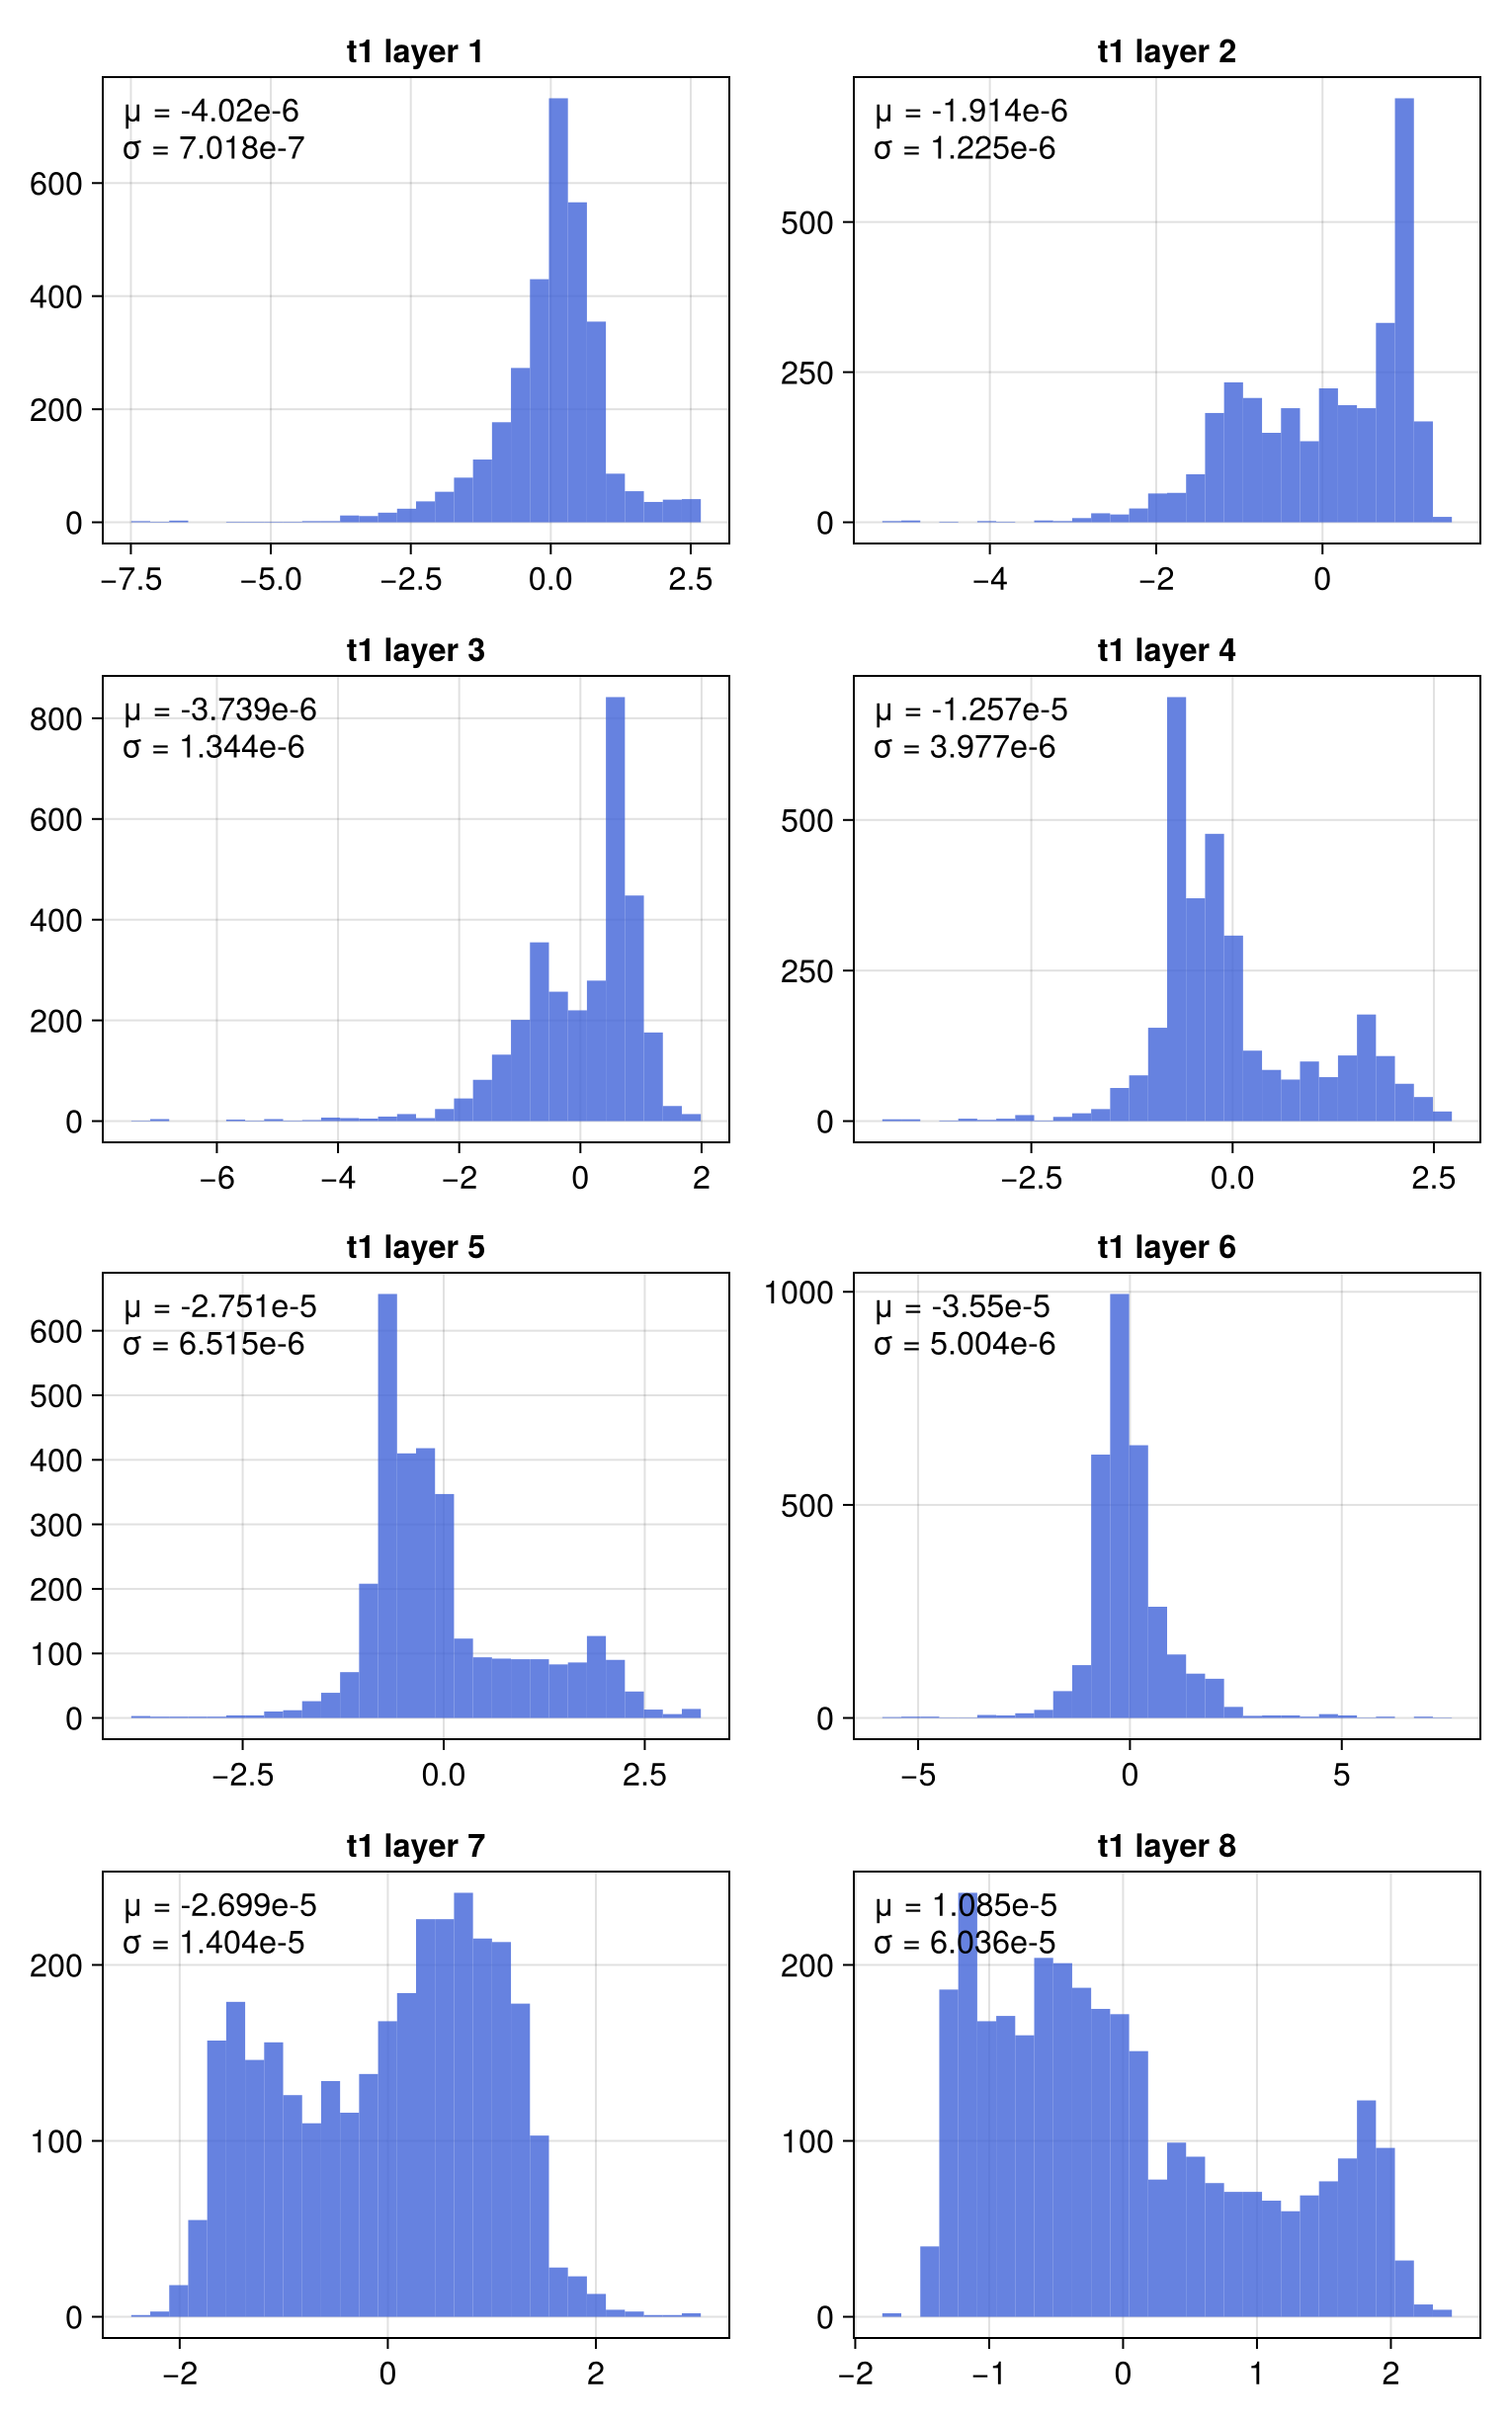

In [77]:
# Linear: Temperature, constant terms
h_t1_linear =plot_hist(coeffs.linear.coeffs, zs.linear, (:t1), style=sc)

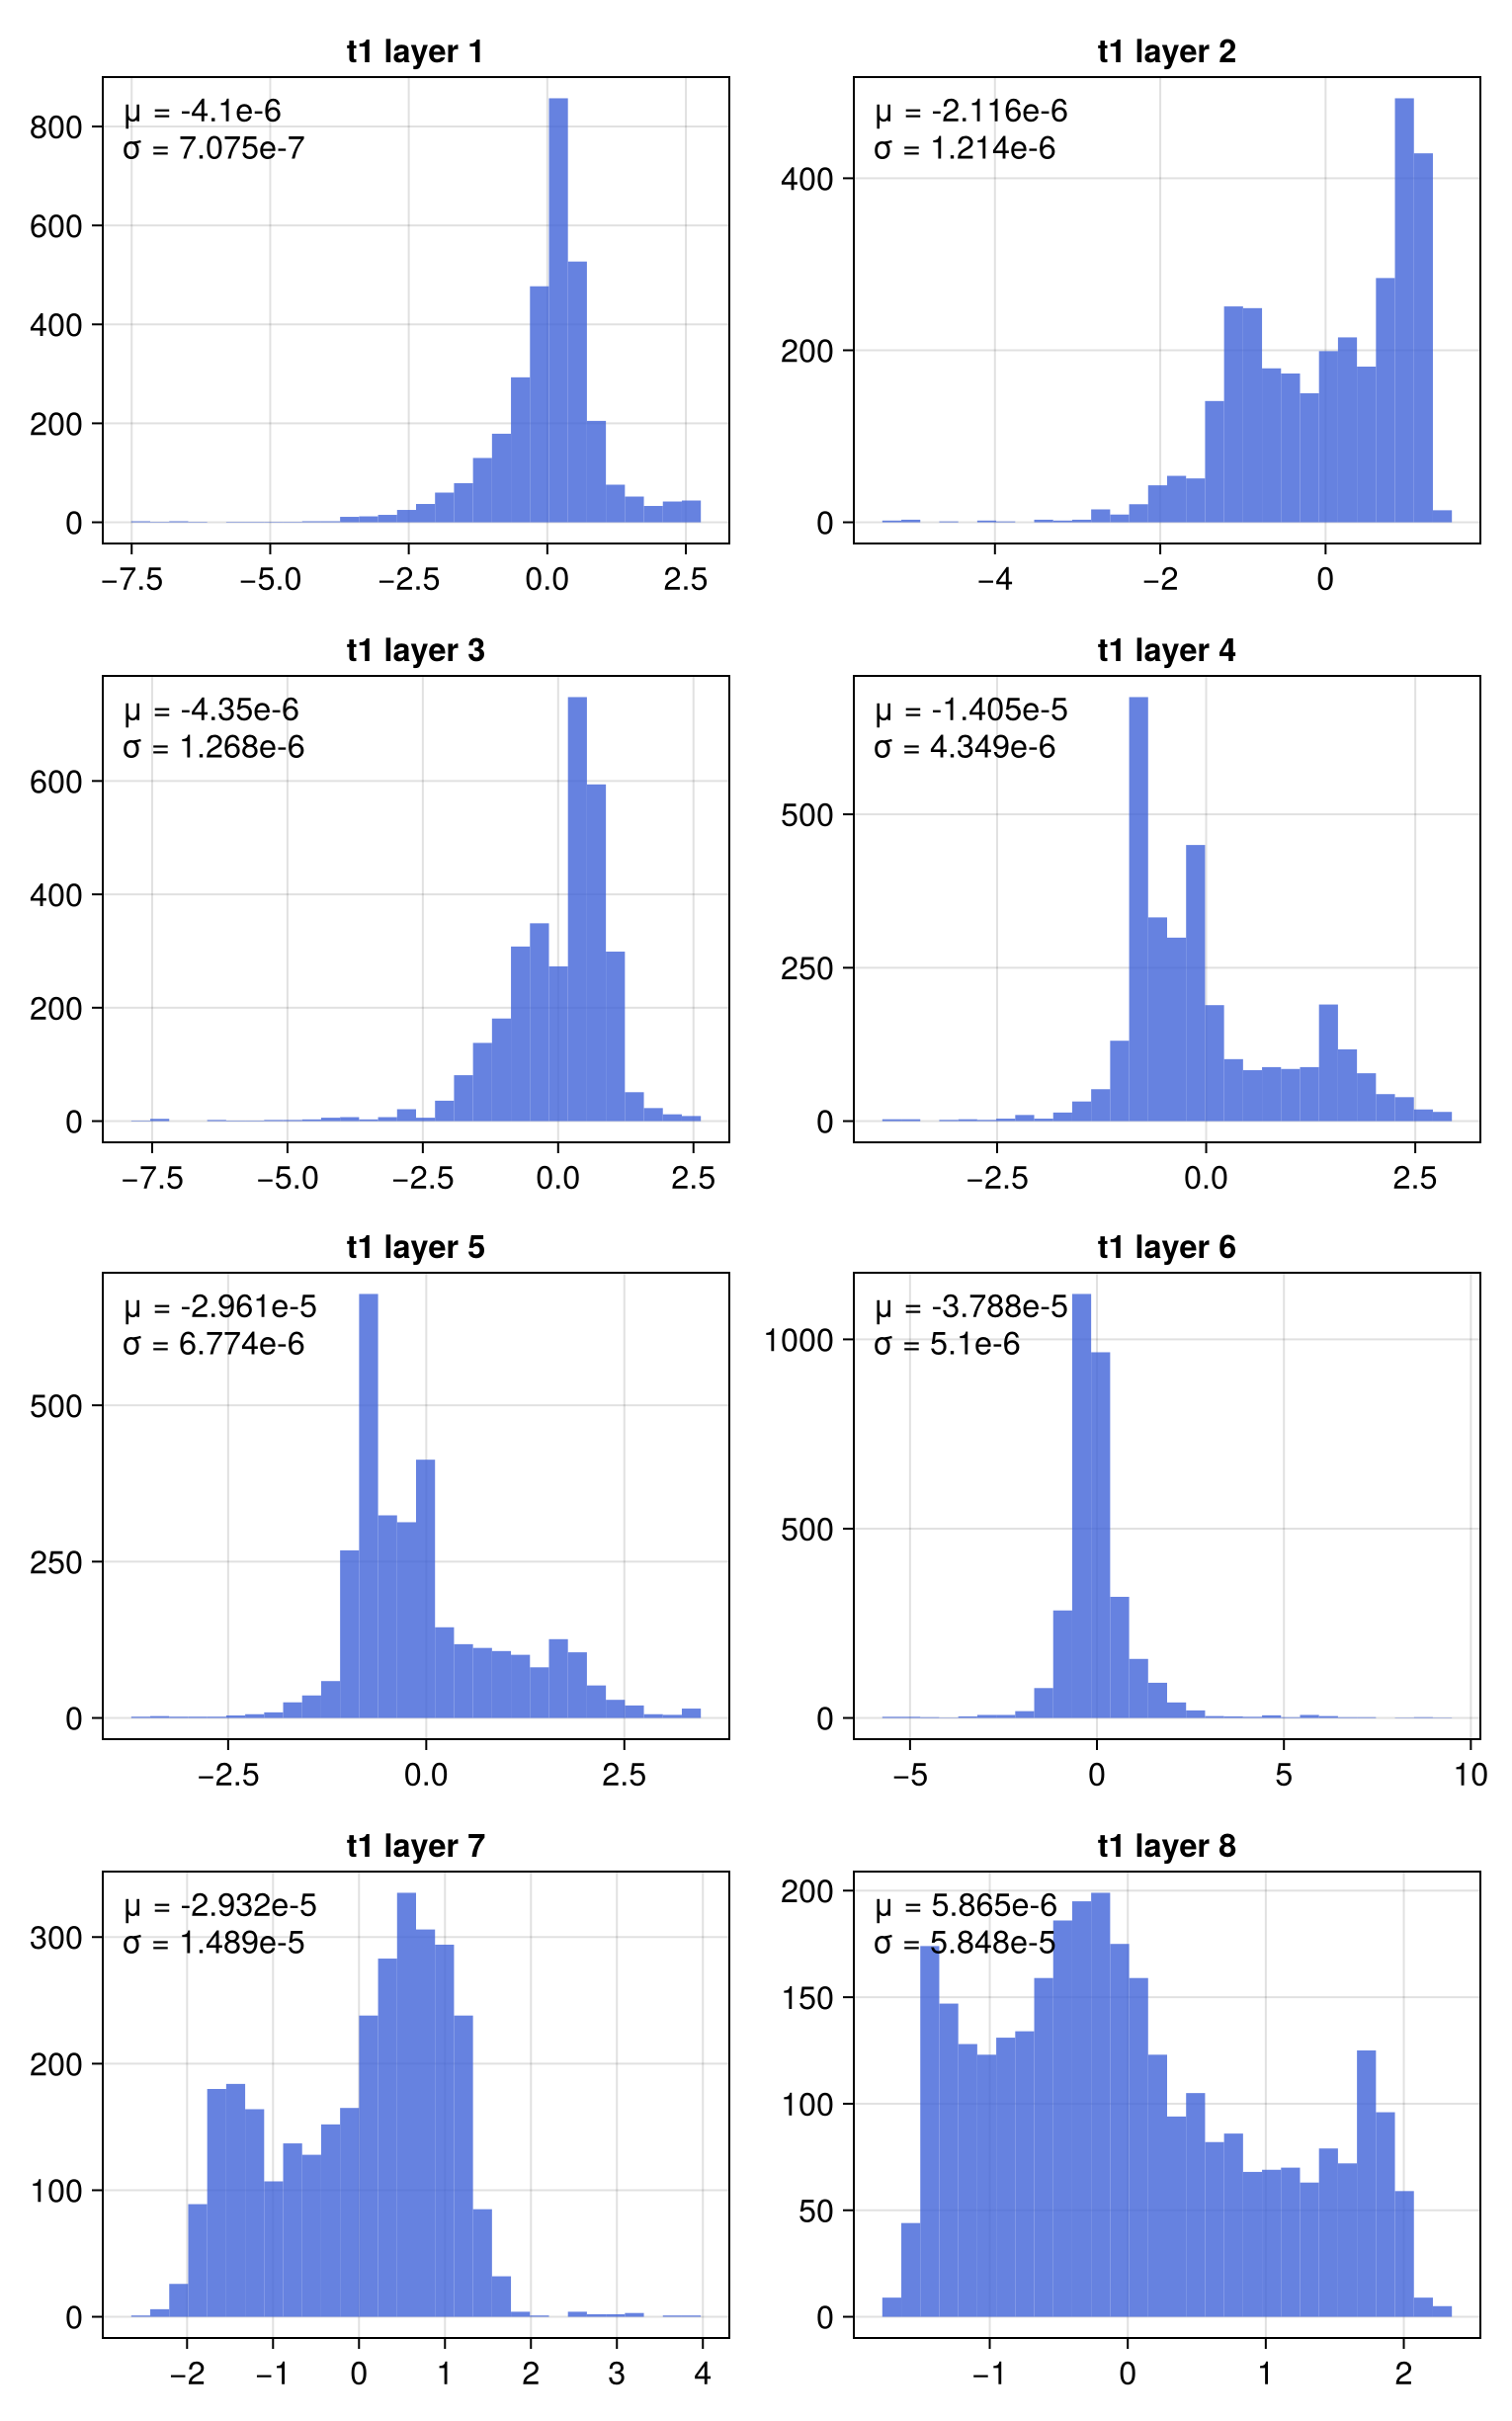

In [78]:
# Planck: Temperature, constant terms
h_t1_planck =plot_hist(coeffs.planck.coeffs, zs.planck, (:t1), style=sc)

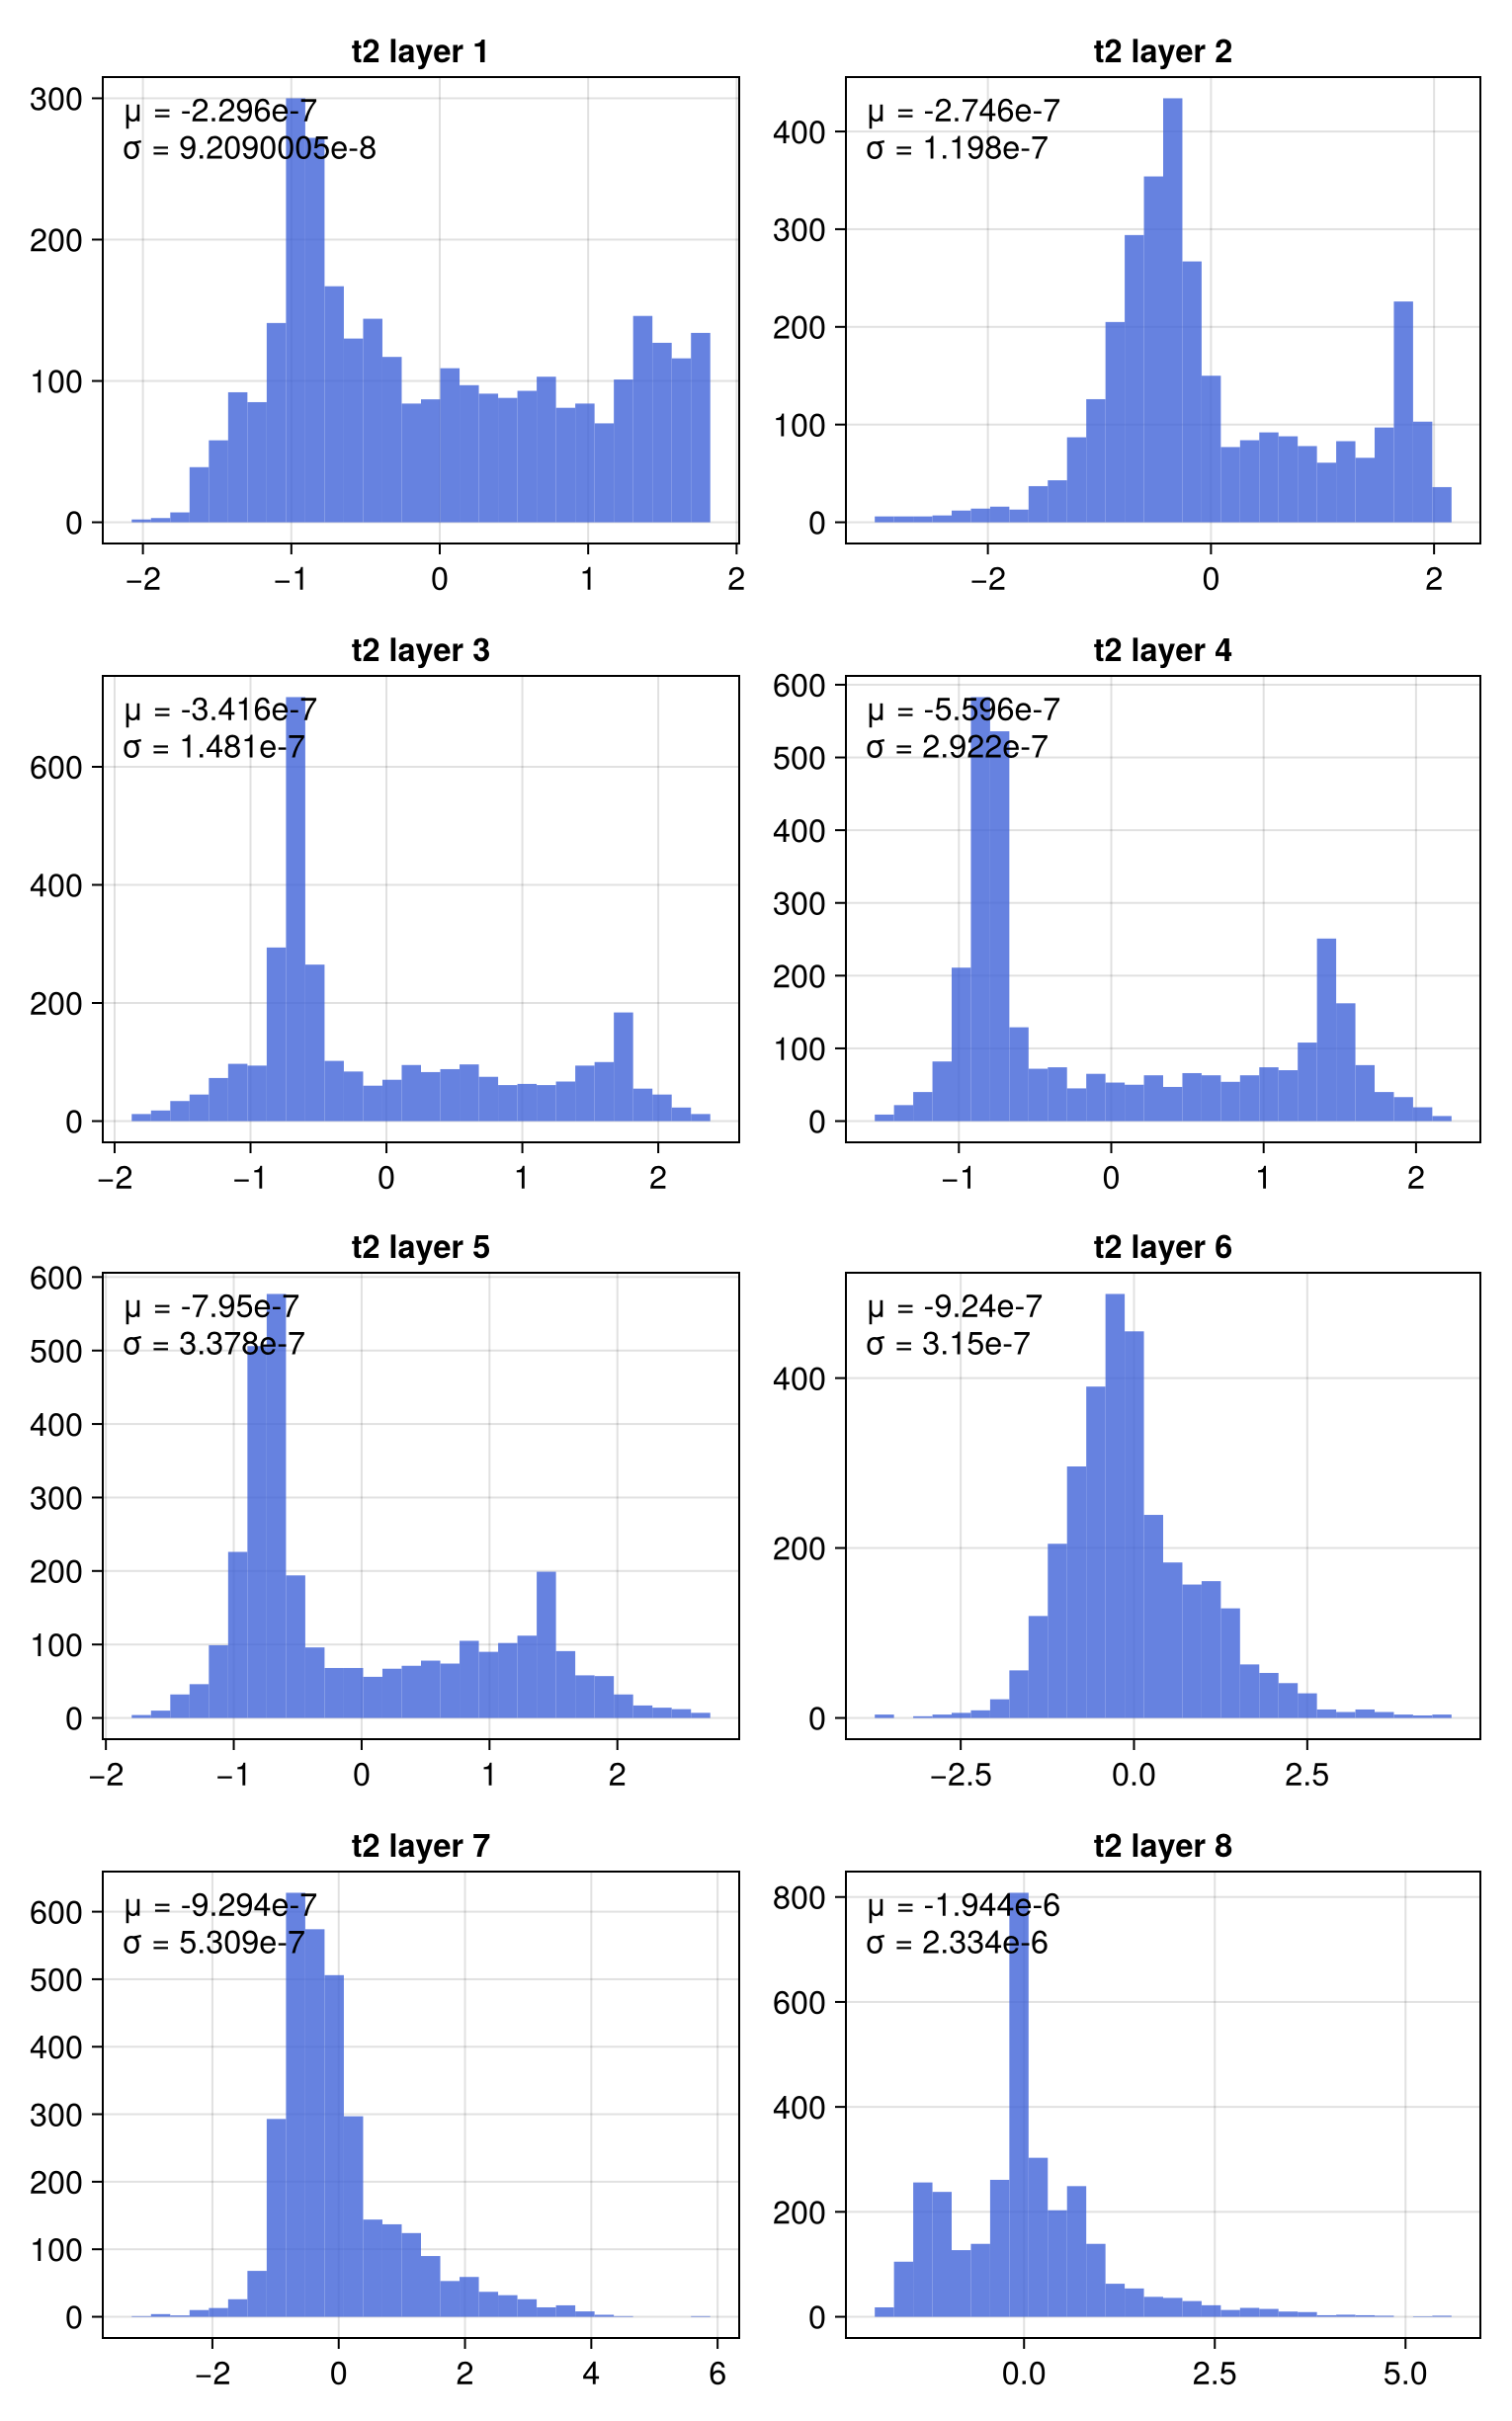

In [79]:
# Linear: Temperature, linear terms
h_t2_linear =plot_hist(coeffs.linear.coeffs, zs.linear, (:t2), style=sc)

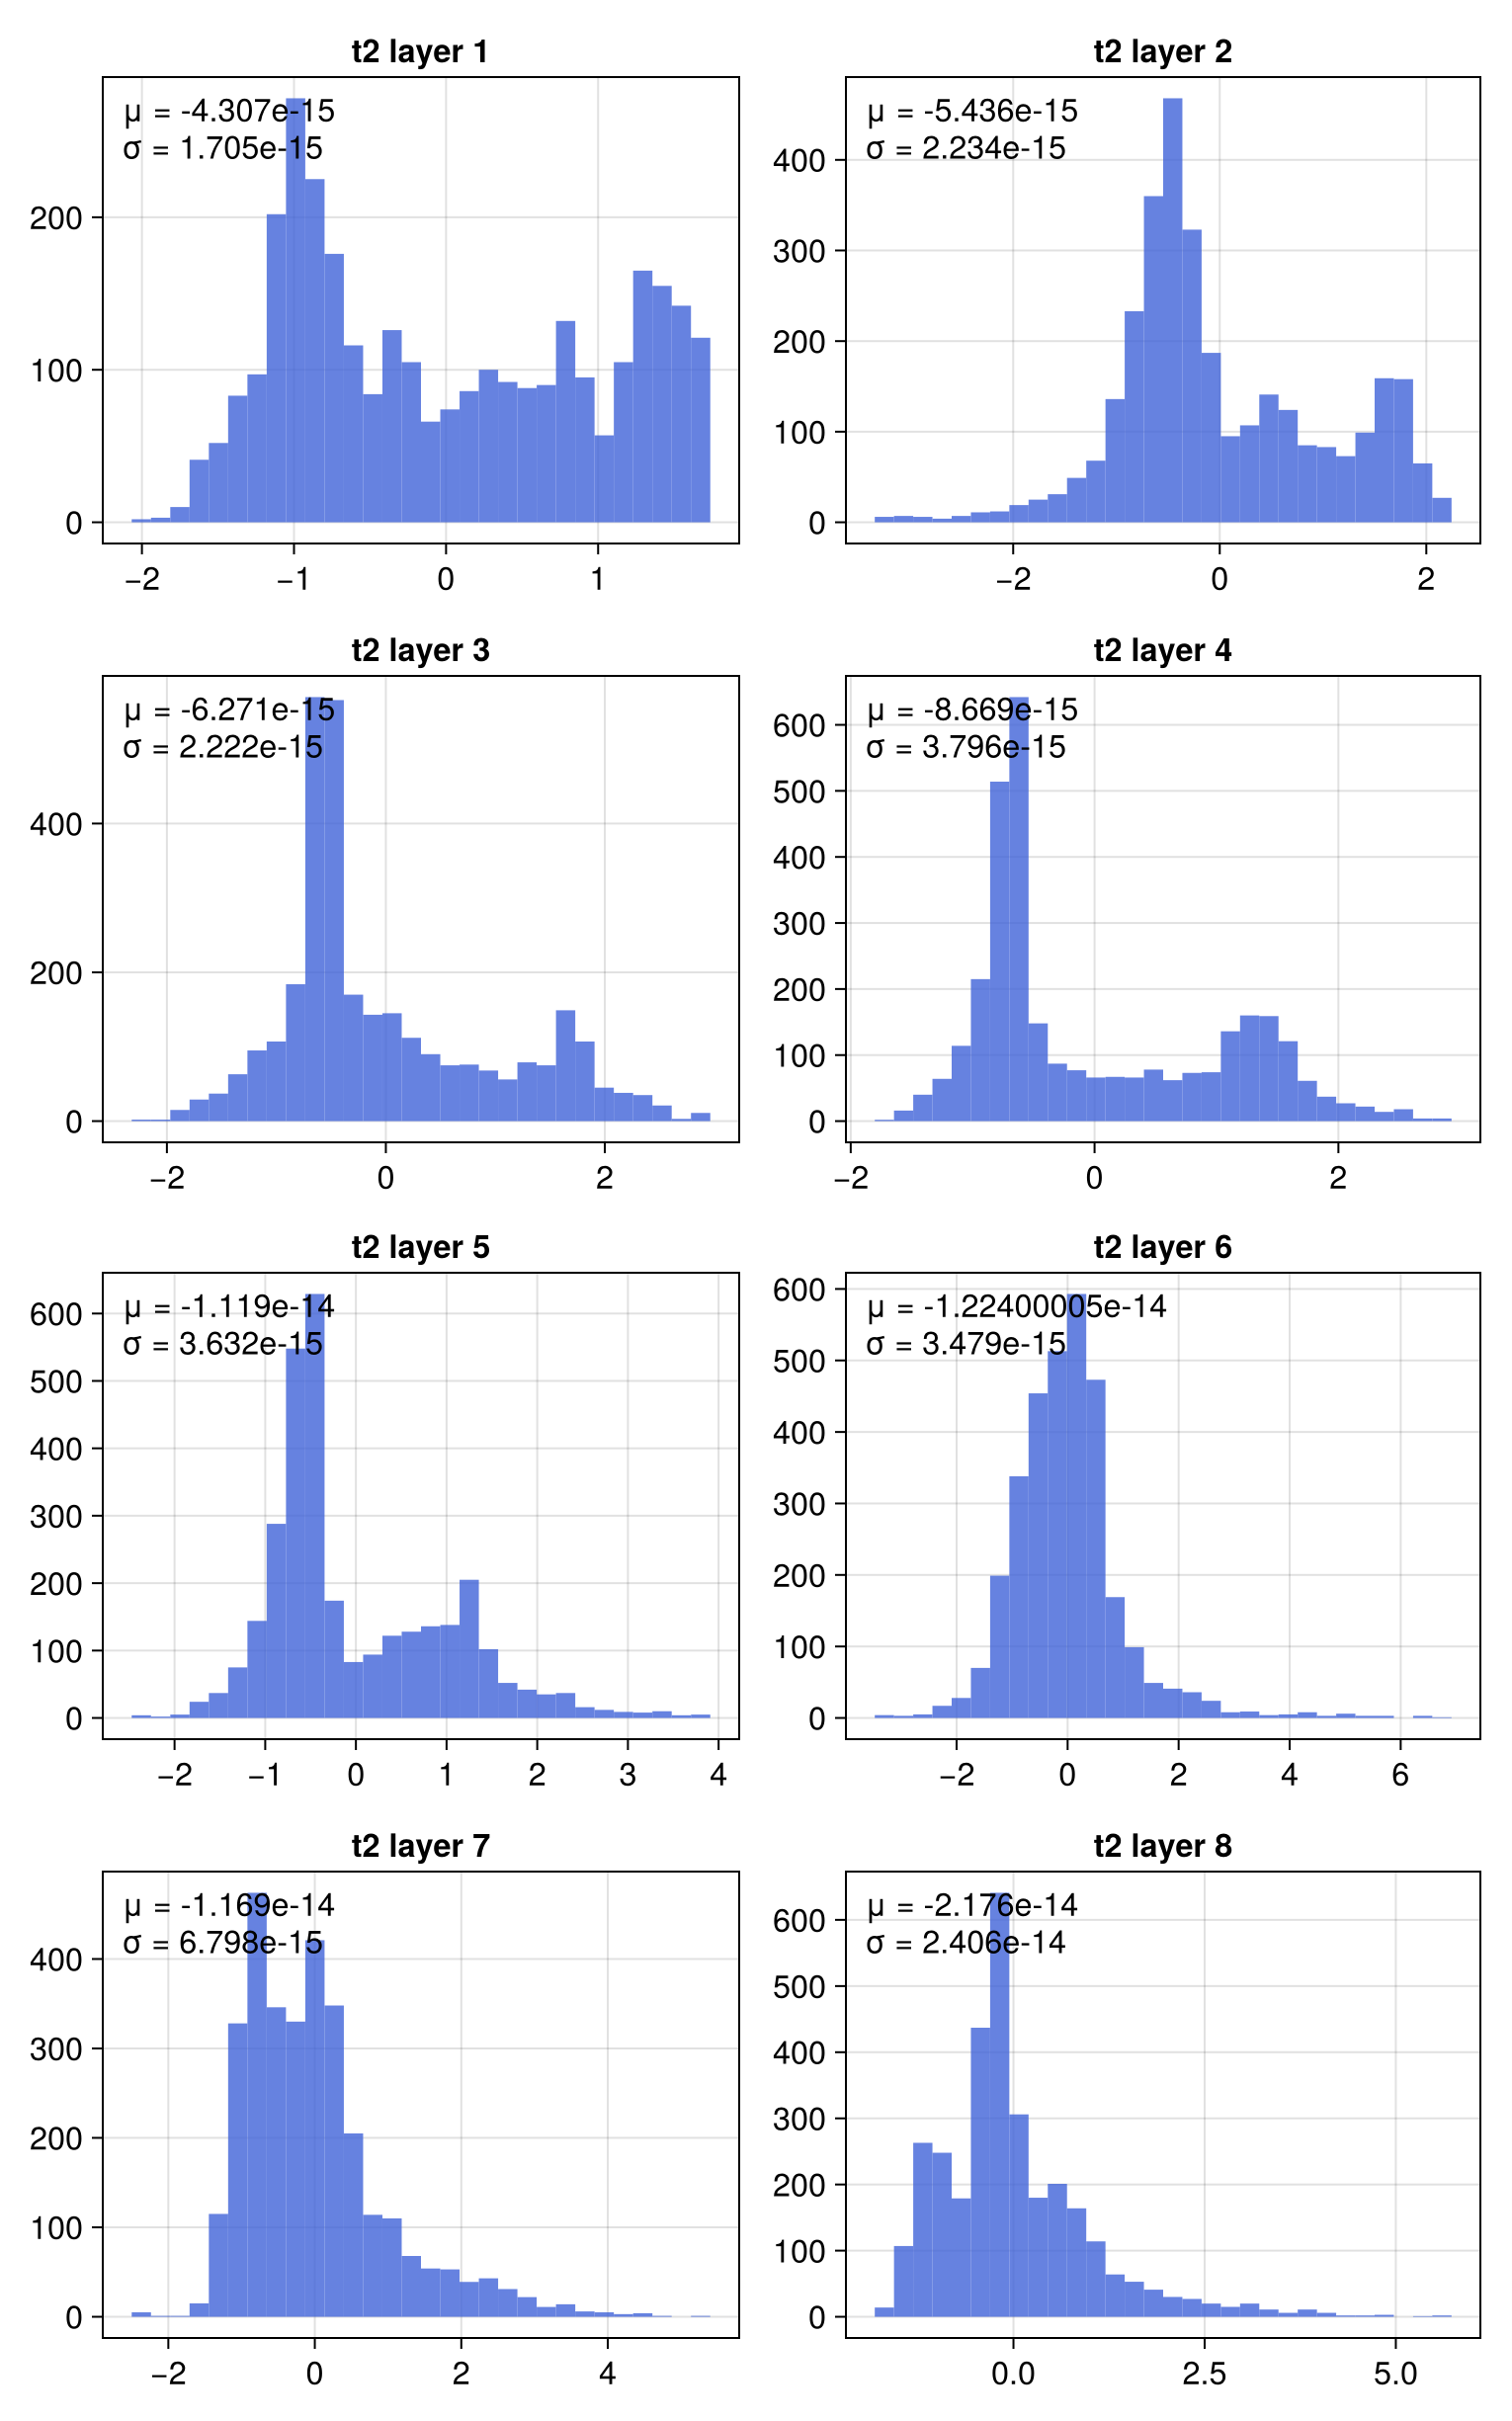

In [80]:
# Planck: Temperature, linear term
h_t2_planck =plot_hist(coeffs.planck.coeffs, zs.planck, (:t2), style=sc)

#### 2.2.2. Fluxes

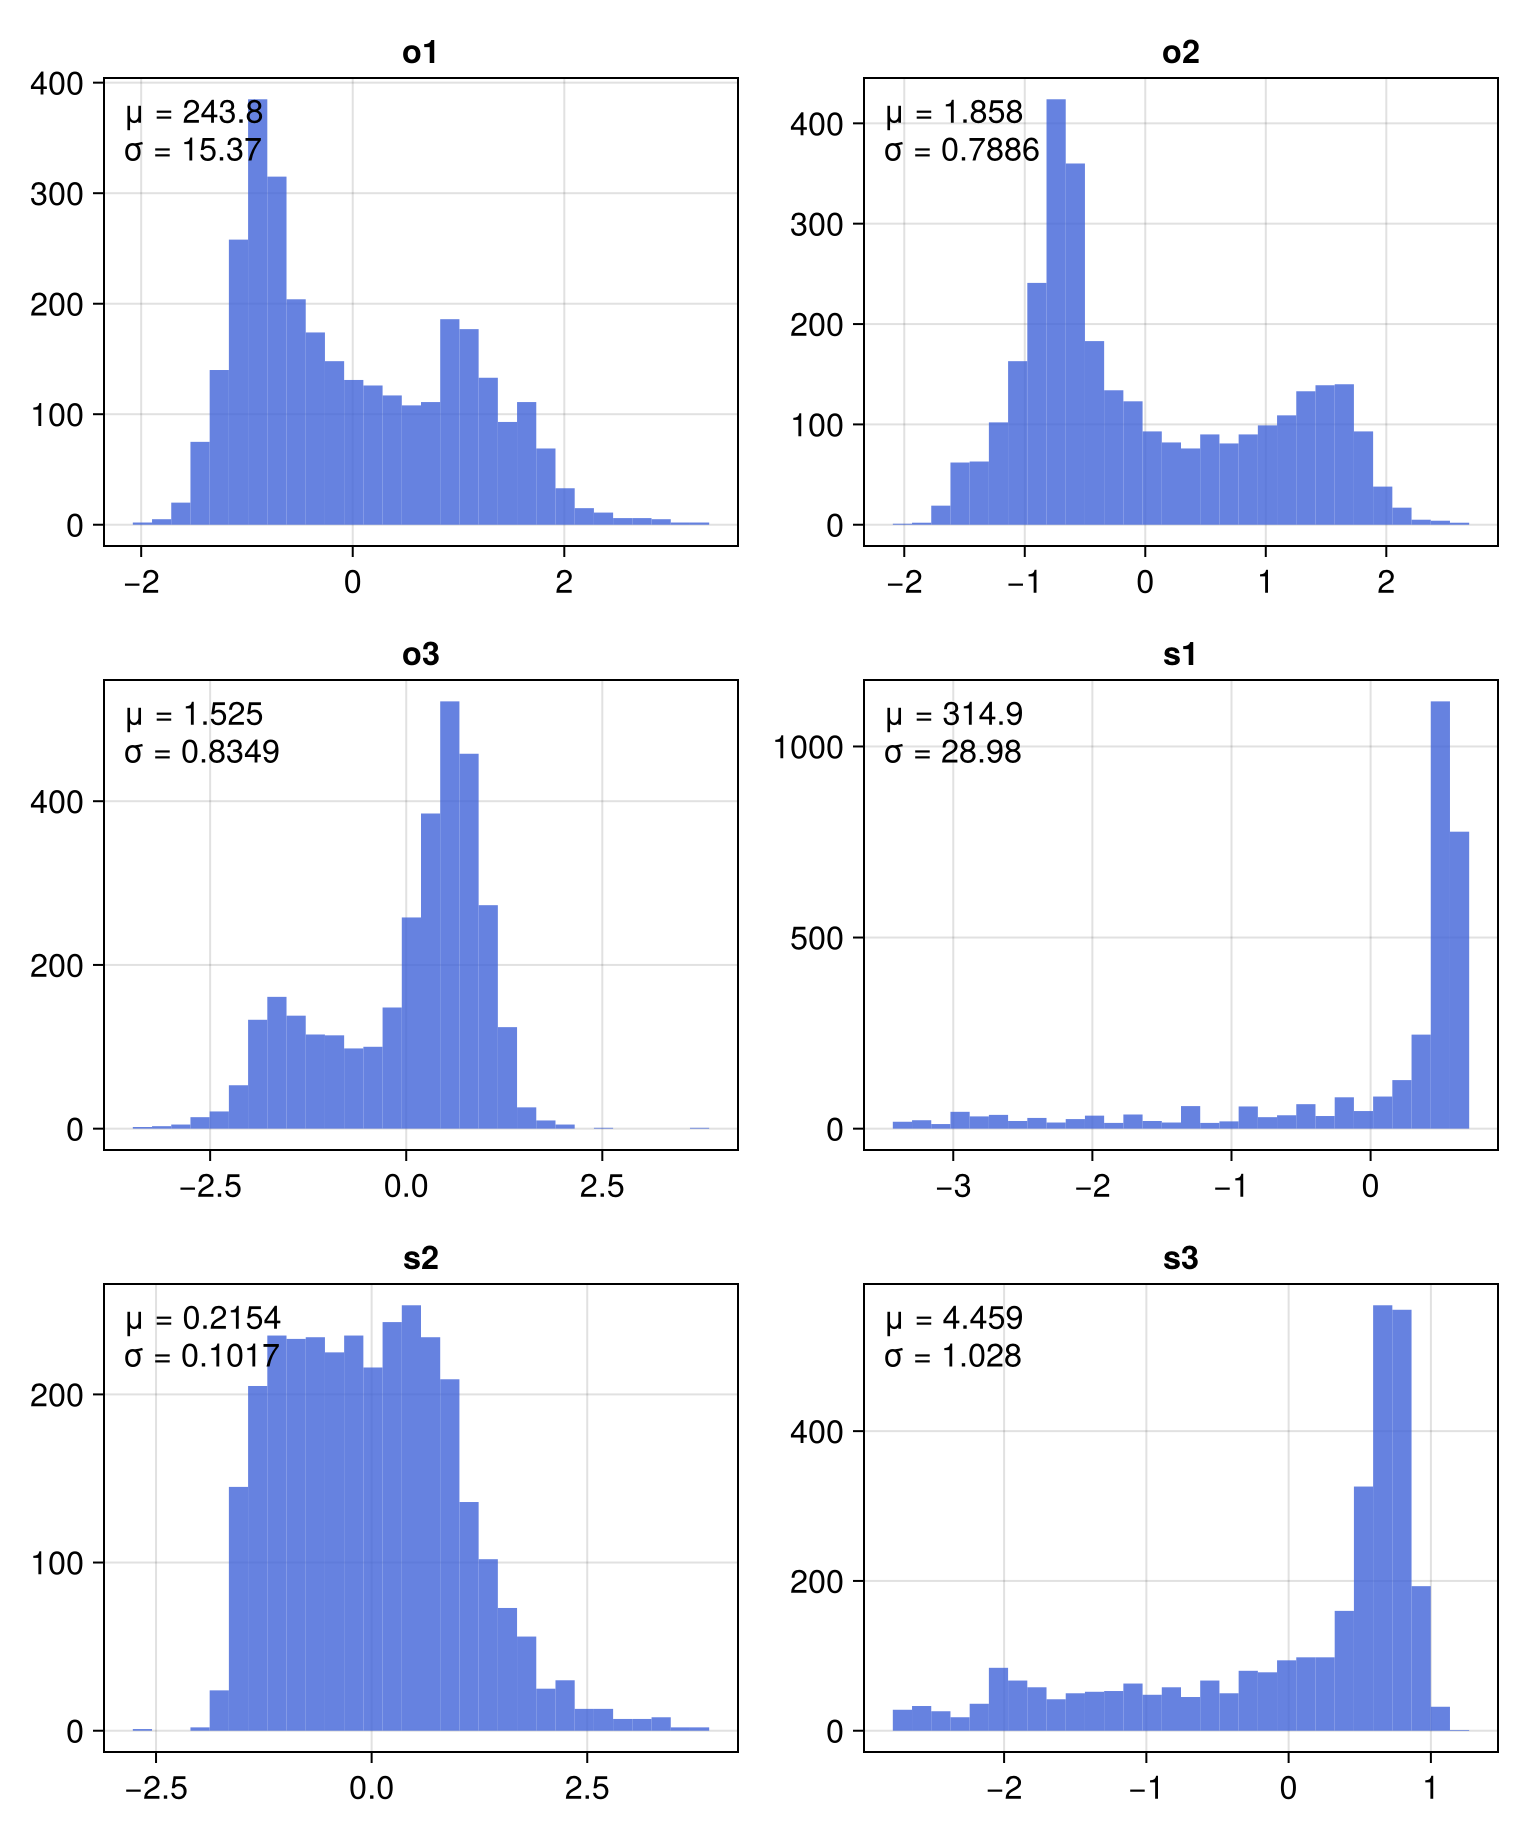

In [81]:
# Linear: Fluxes
h_fluxes_linear =plot_hist(coeffs.linear.coeffs, zs.linear, (:o1, :o2, :o3, :s1, :s2, :s3), style=sc)

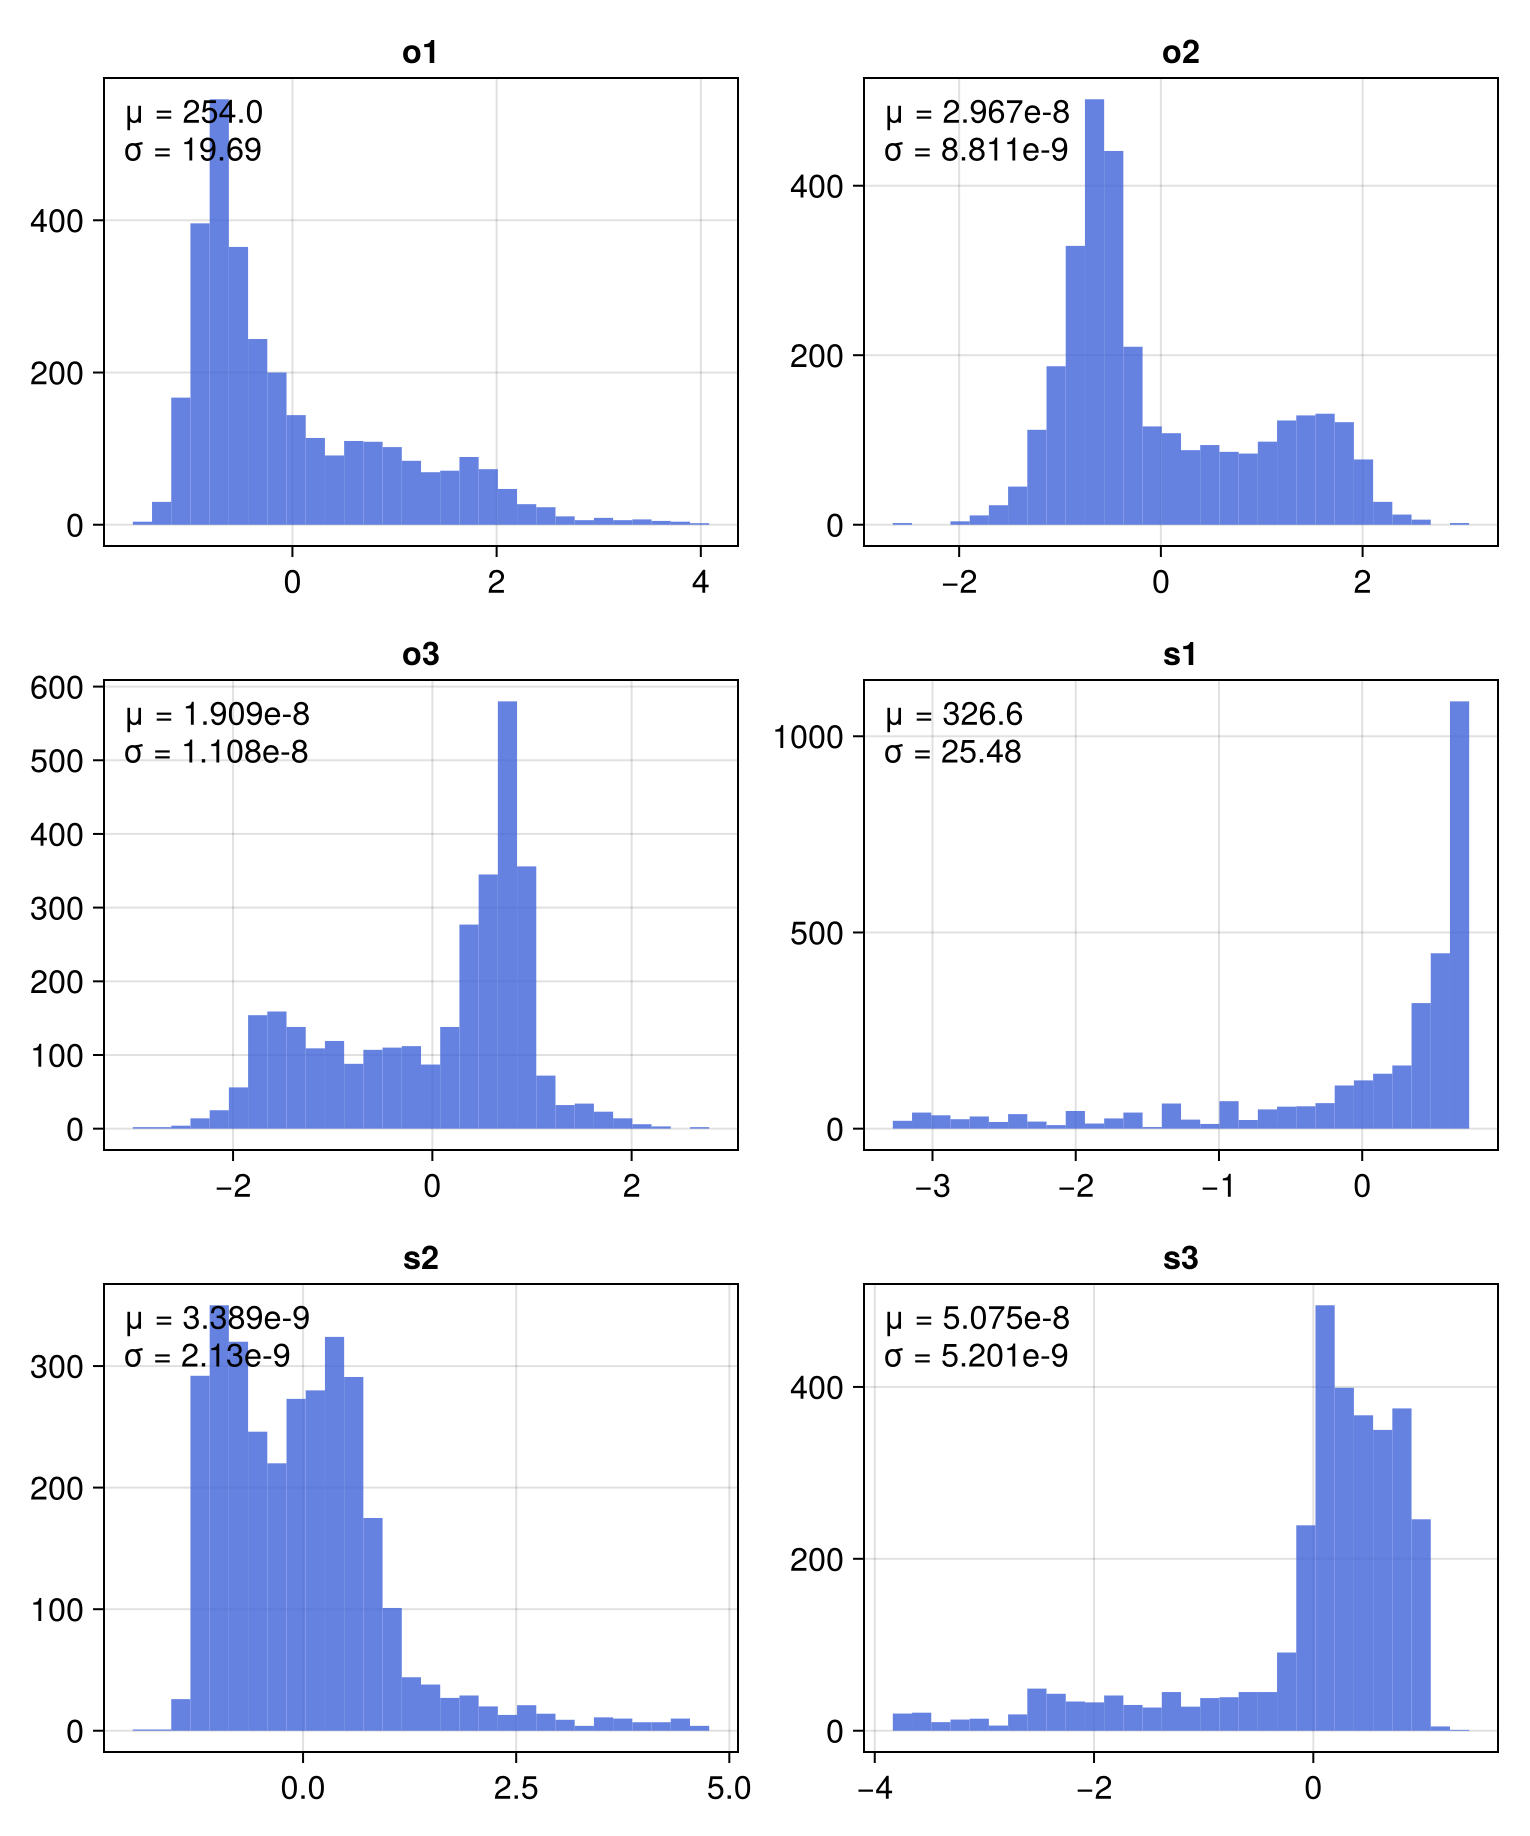

In [82]:
# Planck: Fluxes
h_fluxes_planck =plot_hist(coeffs.planck.coeffs, zs.planck, (:o1, :o2, :o3, :s1, :s2, :s3), style=sc)

### 2.3. Save Plots

In [83]:
# Create dir
dir = prepare_out_dir(zscore_dir("OBLW", "default"); name = "plots_distribution", overwrite=true);

In [87]:
# Save IO histograms
save_figure(h_T,            joinpath(dir, "hist_T.png"))
save_figure(h_dT,           joinpath(dir, "hist_dT.png"))
save_figure(h_flux,         joinpath(dir, "hist_flux.png"))
save_figure(h_scalar,       joinpath(dir, "hist_scalar.png"));
save_figure(h_net_fluxes,   joinpath(dir, "hist_net_fluxes.png"));

In [85]:
# Save OF coefficients histograms
save_figure(h_t1_linear,        joinpath(dir, "hist_t1_linear.png"))
save_figure(h_t1_planck,        joinpath(dir, "hist_t1_planck.png"))
save_figure(h_t2_linear,        joinpath(dir, "hist_t2_linear.png"))
save_figure(h_t2_planck,        joinpath(dir, "hist_t2_planck.png"))

save_figure(h_fluxes_linear,    joinpath(dir, "hist_fluxes_linear.png"))
save_figure(h_fluxes_planck,    joinpath(dir, "hist_fluxes_planck.png"))

"c:\\Code\\NeuralLongwave.jl\\data\\zscore\\OBLW\\default\\plots_distribution\\hist_fluxes_planck.png"